In [2]:
from pathlib import Path

# Project directory
PROJECT_DIR = Path.cwd().parent

# Dataset directory
DATA_DIR = PROJECT_DIR / "data" / "raw" / "TCGA-PANCAN-HiSeq-801x20531"

print("Dataset directory:")
print(DATA_DIR)

print("\nFiles:")
for file in DATA_DIR.iterdir():
    print(file.name)

Dataset directory:
c:\Users\Ishika Jaiswal\Desktop\cancer-gene-expression-ml\data\raw\TCGA-PANCAN-HiSeq-801x20531

Files:
data.csv
labels.csv


In [3]:
# File paths
DATA_FILE = DATA_DIR / "data.csv"
LABEL_FILE = DATA_DIR / "labels.csv"

# Check file sizes
print("Expression data size:",
      round(DATA_FILE.stat().st_size / (1024**3), 2), "GB")

print("Labels file size:",
      round(LABEL_FILE.stat().st_size / (1024**2), 2), "MB")

Expression data size: 0.19 GB
Labels file size: 0.01 MB


In [4]:
with open(LABEL_FILE, "r") as f:
    print("LABELS FILE:")
    for _ in range(10):
        line = f.readline()
        if not line:
            break
        print(line.strip())

LABELS FILE:
,Class
sample_0,PRAD
sample_1,LUAD
sample_2,PRAD
sample_3,PRAD
sample_4,BRCA
sample_5,PRAD
sample_6,KIRC
sample_7,PRAD
sample_8,BRCA


In [5]:
with open(DATA_FILE, "r") as f:
    print("DATA FILE:")
    for _ in range(3):
        line = f.readline()
        if not line:
            break
        print(line[:1000].strip())

DATA FILE:
,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,gene_10,gene_11,gene_12,gene_13,gene_14,gene_15,gene_16,gene_17,gene_18,gene_19,gene_20,gene_21,gene_22,gene_23,gene_24,gene_25,gene_26,gene_27,gene_28,gene_29,gene_30,gene_31,gene_32,gene_33,gene_34,gene_35,gene_36,gene_37,gene_38,gene_39,gene_40,gene_41,gene_42,gene_43,gene_44,gene_45,gene_46,gene_47,gene_48,gene_49,gene_50,gene_51,gene_52,gene_53,gene_54,gene_55,gene_56,gene_57,gene_58,gene_59,gene_60,gene_61,gene_62,gene_63,gene_64,gene_65,gene_66,gene_67,gene_68,gene_69,gene_70,gene_71,gene_72,gene_73,gene_74,gene_75,gene_76,gene_77,gene_78,gene_79,gene_80,gene_81,gene_82,gene_83,gene_84,gene_85,gene_86,gene_87,gene_88,gene_89,gene_90,gene_91,gene_92,gene_93,gene_94,gene_95,gene_96,gene_97,gene_98,gene_99,gene_100,gene_101,gene_102,gene_103,gene_104,gene_105,gene_106,gene_107,gene_108,gene_109,gene_110,gene_111,gene_112,gene_113,gene_114,gene_115,gene_116,gene_117,gene_118,gene_119,gene_120,gene_121,

In [6]:
import pandas as pd
import numpy as np

# Load gene expression data
expression_data = pd.read_csv(DATA_FILE, index_col=0)

# Load cancer labels
labels = pd.read_csv(LABEL_FILE)

print("Expression data shape:", expression_data.shape)
print("Labels shape:", labels.shape)

print("\nExpression data:")
display(expression_data.head())

print("\nLabels:")
display(labels.head())

Expression data shape: (801, 20531)
Labels shape: (801, 2)

Expression data:


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0



Labels:


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


today

In [13]:
# Clean and organize the labels

# Rename the label columns
labels.columns = ["sample_id", "cancer_type"]

# Check the label information
print("Cancer types:")
print(labels["cancer_type"].unique())

print("\nNumber of cancer types:", labels["cancer_type"].nunique())

print("\nClass distribution:")
print(labels["cancer_type"].value_counts())

print("\nFirst 5 labels:")
display(labels.head())

Cancer types:
['PRAD' 'LUAD' 'BRCA' 'KIRC' 'COAD']

Number of cancer types: 5

Class distribution:
cancer_type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

First 5 labels:


,sample_id,cancer_type
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [14]:
# Clean and organize the labels

# Rename columns
labels.columns = ["sample_id", "cancer_type"]

print("Cancer types:")
print(labels["cancer_type"].unique())

print("\nNumber of cancer types:")
print(labels["cancer_type"].nunique())

print("\nClass distribution:")
print(labels["cancer_type"].value_counts())

print("\nFirst 5 labels:")
display(labels.head())

Cancer types:
['PRAD' 'LUAD' 'BRCA' 'KIRC' 'COAD']

Number of cancer types:
5

Class distribution:
cancer_type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

First 5 labels:


,sample_id,cancer_type
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [15]:
# Check whether sample IDs match between expression data and labels

expression_sample_ids = expression_data.index.astype(str)
label_sample_ids = labels["sample_id"].astype(str)

print("Number of expression samples:", len(expression_sample_ids))
print("Number of label samples:", len(label_sample_ids))

print("\nAll sample IDs match:",
      expression_sample_ids.equals(label_sample_ids))

# Check for any missing or extra sample IDs
missing_in_labels = set(expression_sample_ids) - set(label_sample_ids)
missing_in_expression = set(label_sample_ids) - set(expression_sample_ids)

print("\nSamples missing from labels:", len(missing_in_labels))
print("Samples missing from expression data:", len(missing_in_expression))

Number of expression samples: 801
Number of label samples: 801

All sample IDs match: False

Samples missing from labels: 0
Samples missing from expression data: 0


In [16]:
# Check the first few sample IDs in both datasets

print("Expression data sample IDs:")
print(expression_sample_ids[:10].tolist())

print("\nLabel sample IDs:")
print(label_sample_ids[:10].tolist())

Expression data sample IDs:
['sample_0', 'sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5', 'sample_6', 'sample_7', 'sample_8', 'sample_9']

Label sample IDs:
['sample_0', 'sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5', 'sample_6', 'sample_7', 'sample_8', 'sample_9']


In [17]:
# Find positions where sample TDs differ


differences=[
    (i,expression_sample_ids[i],label_sample_ids[i])
    for i in range(len(expression_sample_ids))
    if expression_sample_ids[i]!= label_sample_ids[i]
]
print('Number of positions with different IDs:',len(differences))
print("\nFirst 10 differences:")
for difference in differences[:10]:
    print(difference)

Number of positions with different IDs: 0

First 10 differences:


In [18]:
# Check for missing values in the expression data

missing_values = expression_data.isnull().sum().sum()

print("Total missing values:", missing_values)

if missing_values == 0:
    print("No missing values found in the expression data.")
else:
    print("Missing values are present and need to be handled.")

Total missing values: 0
No missing values found in the expression data.


In [19]:
# Check data types of the expression data

print("Data types:")
print(expression_data.dtypes.value_counts())

Data types:
float64    20531
Name: count, dtype: int64


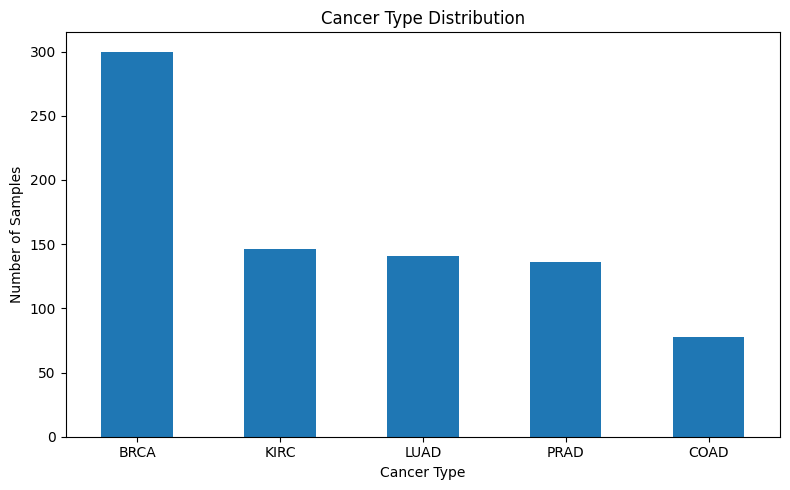

In [20]:
import matplotlib.pyplot as plt

# Count samples in each cancer type
class_counts = labels["cancer_type"].value_counts()

# Plot class distribution
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")

plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Check basic statistics of gene expression values

print("Minimum expression value:", expression_data.min().min())
print("Maximum expression value:", expression_data.max().max())
print("Mean expression value:", expression_data.mean().mean())
print("Median expression value:", expression_data.median().median())

Minimum expression value: 0.0
Maximum expression value: 20.7788287118
Mean expression value: 6.443322266573218
Median expression value: 7.5792178687


In [22]:
# Check for genes with zero variance

gene_variance = expression_data.var(axis=0)

constant_genes = (gene_variance == 0).sum()

print("Total number of genes:", expression_data.shape[1])
print("Number of constant genes:", constant_genes)
print("Number of variable genes:", (gene_variance > 0).sum())

Total number of genes: 20531
Number of constant genes: 267
Number of variable genes: 20264


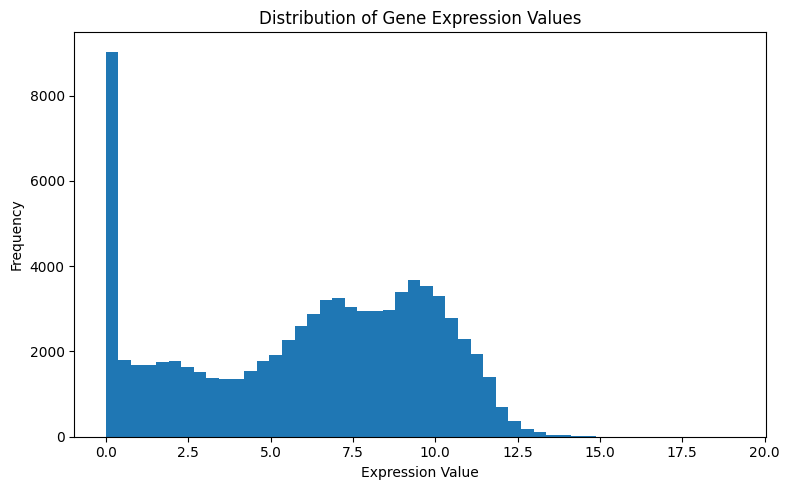

In [23]:
# Plot distribution of gene-expression values

sample_values = expression_data.sample(
    n=100,
    axis=1,
    random_state=42
).values.flatten()

plt.figure(figsize=(8, 5))
plt.hist(sample_values, bins=50)

plt.title("Distribution of Gene Expression Values")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()